<a href="https://colab.research.google.com/github/nikkizahhh1/Data-Augmentation-in-Skin-Lesion-Classification--Honors-Thesis/blob/main/HAM10000_Baseline3_Augmentation_Balanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAM10000 — Baseline 3: Augmentation-Balanced Training Set

This notebook keeps the **same train/validation/test split and ResNet-50 setup** used for the previous baselines, but changes the **training-data distribution**.

### Baseline 3 design
- Keep **all original training images**
- Balance minority classes up to the size of the **largest training class**
- Added minority-class copies receive only these basic augmentations:
  - Random horizontal flip
  - Random vertical flip
  - Random rotation up to ±15°
- Original training images are not altered beyond resize + normalization
- Validation and test sets are **never augmented**
- ResNet-50 with ImageNet initialization
- 7 output classes
- CrossEntropyLoss
- Adam, learning rate = 0.0001
- Batch size = 32
- Maximum 20 epochs
- Early stopping after 5 validation-loss non-improvements
- Checkpoint saved to Google Drive after every epoch

### Files saved to Drive
The notebook saves the training manifest, checkpoints, best model, training history, graphs, test predictions with confidence, per-class metrics, confusion matrix, and final metrics.

> The augmented images are generated **on the fly** during training. They are not saved as separate JPG files. The manifest records which source images were duplicated for augmentation.


In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 2. Imports + reproducibility
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# 3. Paths

BASE_DIR = "/content/drive/MyDrive/HAM10000_Splits"

# Existing split CSVs from Baseline 1
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VAL_CSV   = os.path.join(BASE_DIR, "val.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

# Baseline 3 outputs
OUTPUT_DIR = os.path.join(BASE_DIR, "Baseline3_Augmented_Dropout03")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Outputs will be saved to:")
print(OUTPUT_DIR)


Outputs will be saved to:
/content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03


In [4]:
# 4. Find the split CSVs automatically if they are in a subfolder

def find_csv(filename):
    exact = os.path.join(BASE_DIR, filename)

    if os.path.exists(exact):
        return exact

    matches = glob.glob(
        os.path.join(BASE_DIR, "**", filename),
        recursive=True
    )

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} anywhere under {BASE_DIR}"
        )

    return matches[0]

TRAIN_CSV = find_csv("train.csv")
VAL_CSV   = find_csv("val.csv")
TEST_CSV  = find_csv("test.csv")

print("Train:", TRAIN_CSV)
print("Val:  ", VAL_CSV)
print("Test: ", TEST_CSV)


Train: /content/drive/MyDrive/HAM10000_Splits/train.csv
Val:   /content/drive/MyDrive/HAM10000_Splits/val.csv
Test:  /content/drive/MyDrive/HAM10000_Splits/test.csv


In [5]:
# 5. Load the SAME split used by the previous baselines

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Original split sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print("\nOriginal TRAIN class counts:")
print(train_df["dx"].value_counts().sort_index())


Original split sizes:
Train: 7010
Val:   1502
Test:  1503

Original TRAIN class counts:
dx
akiec     229
bcc       360
bkl       769
df         81
mel       779
nv       4693
vasc       99
Name: count, dtype: int64


In [6]:
# 6. Build the Baseline 3 augmentation-balanced training manifest
#
# Every ORIGINAL training image is kept once.
# Minority classes are expanded to the size of the largest training class.
# Extra rows are sampled WITH replacement and marked is_augmented=True.
#
# The actual random flip/rotation happens later inside the Dataset class.

class_counts = train_df["dx"].value_counts()  #how many time each label under column "dx" appears
target_class_size = int(class_counts.max())   #biggest class

print("Target images per class:", target_class_size)

balanced_parts = []

for label in sorted(train_df["dx"].unique()):
    class_df = train_df[train_df["dx"] == label].copy()

    # Keep every original image
    originals = class_df.copy()
    originals["is_augmented"] = False
    originals["source_image_id"] = originals["image_id"].astype(str)
    originals["augmentation_copy_id"] = 0

    balanced_parts.append(originals)

    # Add sampled copies until this class matches the largest class
    additional_needed = target_class_size - len(class_df)

    if additional_needed > 0:
        augmented_copies = class_df.sample(
            n=additional_needed,
            replace=True,
            random_state=SEED
        ).copy()

        augmented_copies["is_augmented"] = True
        augmented_copies["source_image_id"] = augmented_copies["image_id"].astype(str)
        augmented_copies["augmentation_copy_id"] = np.arange(
            1,
            additional_needed + 1
        )

        balanced_parts.append(augmented_copies)

augmented_train_df = (
    pd.concat(balanced_parts, ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

print("\nBaseline 3 TRAIN counts:")
print(augmented_train_df["dx"].value_counts().sort_index())

print("\nTotal Baseline 3 training rows:", len(augmented_train_df))
print("Original rows:", (~augmented_train_df["is_augmented"]).sum())
print("Augmented-copy rows:", augmented_train_df["is_augmented"].sum())

# Save the exact training manifest
manifest_path = os.path.join(
    OUTPUT_DIR,
    "baseline3_augmented_train_manifest.csv"
)

augmented_train_df.to_csv(manifest_path, index=False)

print("\nSaved training manifest:")
print(manifest_path)


Target images per class: 4693

Baseline 3 TRAIN counts:
dx
akiec    4693
bcc      4693
bkl      4693
df       4693
mel      4693
nv       4693
vasc     4693
Name: count, dtype: int64

Total Baseline 3 training rows: 32851
Original rows: 7010
Augmented-copy rows: 25841

Saved training manifest:
/content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03/baseline3_augmented_train_manifest.csv


In [7]:
# 7. Build image_id -> image path dictionary

image_paths = {}

for folder in [
    "/content/drive/MyDrive/HAM10000_Dataset/Part1",
    "/content/drive/MyDrive/HAM10000_Dataset/Part2"
]:
    for path in glob.glob(folder + "/*.jpg"):
        image_id = os.path.splitext(os.path.basename(path))[0]
        image_paths[image_id] = path

print("Images code found:", len(image_paths))


Images code found: 10016


In [8]:
#diag
print("Images code found:", len(image_paths))
print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

Images code found: 10016
Train rows: 7010
Val rows: 1502
Test rows: 1503


In [9]:
#diag
import os

print(os.listdir("/content/drive/MyDrive/HAM10000_Dataset"))

['Baseline3_Augmented', 'Metadata', 'Part2', 'Part1', 'Baseline2_Undersampled']


In [10]:
# 8. Check for missing images BEFORE training

def missing_images(df):
    return [
        image_id
        for image_id in df["image_id"].astype(str)
        if image_id not in image_paths
    ]

missing_train = missing_images(train_df)
missing_val   = missing_images(val_df)
missing_test  = missing_images(test_df)

print("Missing training images:  ", missing_train)
print("Missing validation images:", missing_val)
print("Missing test images:      ", missing_test)

assert len(missing_train) == 0, "Training images are missing."
assert len(missing_val) == 0, "Validation images are missing."
assert len(missing_test) == 0, "Test images are missing."

print("\nAll required images were found.")


Missing training images:   []
Missing validation images: []
Missing test images:       []

All required images were found.


In [11]:
# 9. Label mapping

classes = sorted(train_df["dx"].unique())

class_to_idx = {
    label: i
    for i, label in enumerate(classes)
}

idx_to_class = {
    i: label
    for label, i in class_to_idx.items()
}

print(class_to_idx)


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [12]:
# 10. Transforms
#
# Original training images:
#   resize + tensor + normalization only
#
# Added minority-class copies:
#   horizontal flip + vertical flip + rotation up to ±15°
#
# Validation/test:
#   resize + tensor + normalization only

base_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

augmented_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [13]:
# 11. Dataset class
#
# is_augmented determines whether the image gets the basic augmentation transform.

class HAM10000Baseline3Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_paths,
        class_to_idx,
        base_transform,
        augmented_transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_paths = image_paths
        self.class_to_idx = class_to_idx
        self.base_transform = base_transform
        self.augmented_transform = augmented_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_id = str(row["image_id"])
        label_name = row["dx"]
        label = self.class_to_idx[label_name]

        image = Image.open(
            self.image_paths[image_id]
        ).convert("RGB")

        use_augmentation = (
            "is_augmented" in row.index
            and bool(row["is_augmented"])
            and self.augmented_transform is not None
        )

        if use_augmentation:
            image = self.augmented_transform(image)
        else:
            image = self.base_transform(image)

        return image, label, image_id


In [14]:
# 12. Create datasets and DataLoaders

train_dataset = HAM10000Baseline3Dataset(
    augmented_train_df,
    image_paths,
    class_to_idx,
    base_transform=base_train_transform,
    augmented_transform=augmented_train_transform
)

val_dataset = HAM10000Baseline3Dataset(
    val_df,
    image_paths,
    class_to_idx,
    base_transform=eval_transform
)

test_dataset = HAM10000Baseline3Dataset(
    test_df,
    image_paths,
    class_to_idx,
    base_transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training images/rows:", len(train_dataset))
print("Validation images:   ", len(val_dataset))
print("Test images:         ", len(test_dataset))

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training images/rows: 32851
Validation images:    1502
Test images:          1503

Training batches: 1027
Validation batches: 47
Test batches: 47


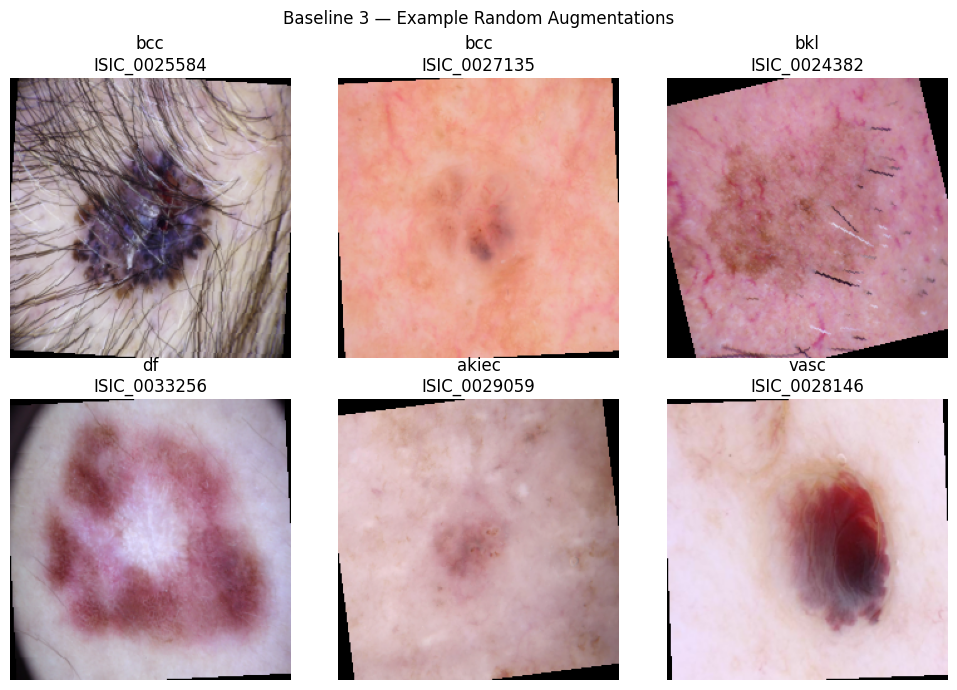

Saved preview:
/content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03/augmentation_preview.png


In [15]:
# 13. Preview several augmented copies before training
#
# This lets you visually verify that the augmentations are reasonable.

preview_df = augmented_train_df[
    augmented_train_df["is_augmented"] == True
].head(6)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, (_, row) in zip(axes.flatten(), preview_df.iterrows()):
    image_id = str(row["image_id"])

    image = Image.open(
        image_paths[image_id]
    ).convert("RGB")

    # Apply the same random augmentation transform used during training
    transformed = augmented_train_transform(image)

    # Undo normalization only for display
    display_tensor = transformed.clone()

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    display_tensor = (
        display_tensor * std + mean
    ).clamp(0, 1)

    ax.imshow(
        display_tensor.permute(1, 2, 0)
    )

    ax.set_title(
        f'{row["dx"]}\n{image_id}'
    )

    ax.axis("off")

plt.suptitle("Baseline 3 — Example Random Augmentations")
plt.tight_layout()

preview_path = os.path.join(
    OUTPUT_DIR,
    "augmentation_preview.png"
)

plt.savefig(
    preview_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved preview:")
print(preview_path)


In [16]:
# 14. SAME model architecture/hyperparameters used for Baseline 2


model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 7)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=7, bias=True)
)


In [17]:
# 15. Training configuration

MAX_EPOCHS = 20
PATIENCE = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

history_path = os.path.join(
    OUTPUT_DIR,
    "training_history.csv"
)

best_model_path = os.path.join(
    OUTPUT_DIR,
    "best_model.pth"
)


In [18]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# --------------------
# RESUME DROPOUT RUN IF A DROPOUT CHECKPOINT EXISTS
# --------------------

checkpoint_files = sorted(
    glob.glob(
        os.path.join(
            CHECKPOINT_DIR,
            "baseline3_dropout_epoch_*.pth"
        )
    )
)

start_epoch = 1

if checkpoint_files:

    latest_checkpoint_path = checkpoint_files[-1]

    print(
        "Found previous dropout checkpoint:",
        latest_checkpoint_path
    )

    checkpoint = torch.load(
        latest_checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    train_accuracies = checkpoint["train_accuracies"]
    val_accuracies = checkpoint["val_accuracies"]

    best_val_loss = min(val_losses)
    best_epoch = val_losses.index(best_val_loss) + 1

    start_epoch = checkpoint["epoch"] + 1

    print(f"Resuming from epoch {start_epoch}")

else:

    print(
        "No dropout checkpoint found. "
        "Starting dropout run from epoch 1."
    )

Found previous dropout checkpoint: /content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03/checkpoints/baseline3_dropout_epoch_20.pth
Resuming from epoch 21


In [19]:
# --------------------
# TRAINING LOOP
# --------------------

for epoch in range(start_epoch, MAX_EPOCHS + 1):

    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")

    # =========================
    # TRAIN
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels, image_ids in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_train_loss += loss.item() * images.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    epoch_train_loss = (
        running_train_loss / train_total
    )

    epoch_train_accuracy = (
        train_correct / train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels, image_ids in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)

            running_val_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    epoch_val_loss = (
        running_val_loss / val_total
    )

    epoch_val_accuracy = (
        val_correct / val_total
    )


    # =========================
    # SAVE HISTORY
    # =========================

    train_losses.append(
        epoch_train_loss
    )

    val_losses.append(
        epoch_val_loss
    )

    train_accuracies.append(
        epoch_train_accuracy
    )

    val_accuracies.append(
        epoch_val_accuracy
    )


    print(
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    print(
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )


    # =========================
    # CHECK BEST MODEL
    # =========================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        best_epoch = epoch

        epochs_without_improvement = 0

        best_model_path = os.path.join(
            OUTPUT_DIR,
            "best_model.pth"
        )

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"New best model saved at epoch {epoch}"
        )

    else:

        epochs_without_improvement += 1


    # =========================
    # SAVE CHECKPOINT
    # =========================

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            epoch_train_loss,

        "val_loss":
            epoch_val_loss,

        "train_accuracy":
            epoch_train_accuracy,

        "val_accuracy":
            epoch_val_accuracy,

        "train_losses":
            train_losses,

        "val_losses":
            val_losses,

        "train_accuracies":
            train_accuracies,

        "val_accuracies":
            val_accuracies,

        "best_val_loss":
            best_val_loss,

        "best_epoch":
            best_epoch,

        "epochs_without_improvement":
            epochs_without_improvement,

        "class_to_idx":
            class_to_idx,

        "target_class_size":
            target_class_size,

        "seed":
            SEED
    }


    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"baseline3_dropout_epoch_{epoch:02d}.pth"
    )

    torch.save(
        checkpoint,
        checkpoint_path
    )

    print(
        "Checkpoint saved:",
        checkpoint_path
    )


    # =========================
    # EARLY STOPPING
    # =========================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"Early stopping after epoch {epoch}"
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        break

In [20]:
import pandas as pd

history_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_df.to_csv(history_path, index=False)

history_df = pd.read_csv(history_path)

# Add epoch column
history_df.insert(0, "epoch", range(1, len(history_df) + 1))

# Save updated CSV
history_df.to_csv(history_path, index=False)

print(history_df.head())

   epoch  train_loss  val_loss  train_accuracy  val_accuracy
0      1    0.382462  0.435980        0.867523      0.840213
1      2    0.098251  0.387712        0.965085      0.869507
2      3    0.062694  0.405765        0.978661      0.873502
3      4    0.046858  0.414237        0.984171      0.869507
4      5    0.036894  0.432468        0.987580      0.886152


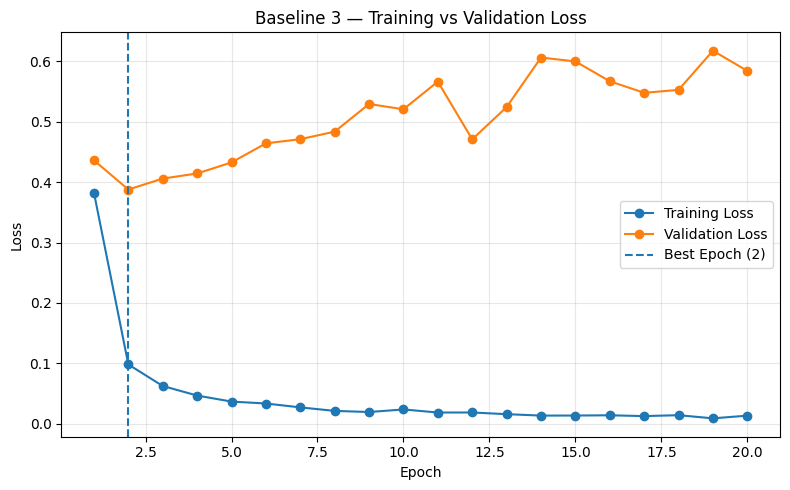

Saved:
/content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03/loss_graph.png


In [21]:
# 17. Plot + save loss graph

history_df = pd.read_csv(
    history_path
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Baseline 3 — Training vs Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_graph_path = os.path.join(
    OUTPUT_DIR,
    "loss_graph.png"
)

plt.savefig(
    loss_graph_path,
    dpi=200
)

plt.show()

print("Saved:")
print(loss_graph_path)


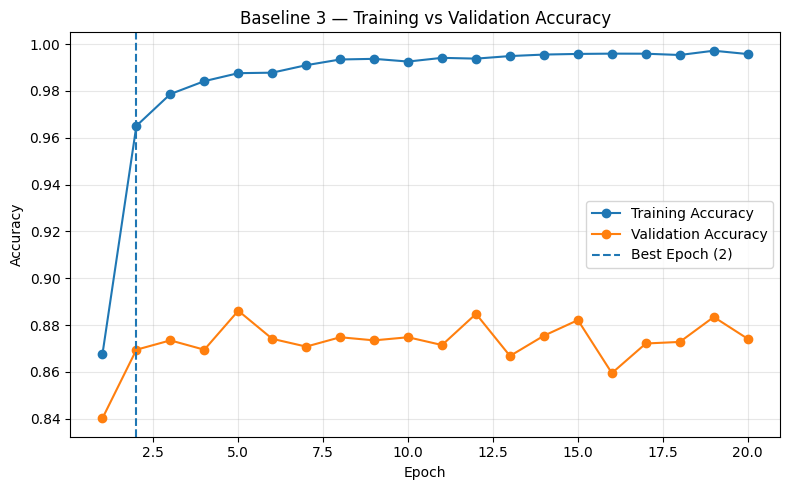

Saved:
/content/drive/MyDrive/HAM10000_Splits/Baseline3_Augmented_Dropout03/accuracy_graph.png


In [22]:
# 18. Plot + save accuracy graph

history_df = pd.read_csv(
    history_path
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Baseline 3 — Training vs Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_graph_path = os.path.join(
    OUTPUT_DIR,
    "accuracy_graph.png"
)

plt.savefig(
    accuracy_graph_path,
    dpi=200
)

plt.show()

print("Saved:")
print(accuracy_graph_path)


In [23]:
print(best_checkpoint.keys())

NameError: name 'best_checkpoint' is not defined

In [ ]:
# 19. Load the BEST checkpoint before test evaluation

best_checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(best_checkpoint)

# Retrieve best epoch and validation loss from CSV
best_row = history_df.loc[history_df["val_loss"].idxmin()]

best_epoch = int(best_row["epoch"])
best_val_loss = float(best_row["val_loss"])

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

In [ ]:
# 20. Evaluate on the unchanged TEST set
#
# Save image-level predictions, correctness, and confidence.

results = []

model.eval()

with torch.no_grad():

    for images, labels, image_ids in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        for (
            image_id,
            true_idx,
            pred_idx,
            confidence
        ) in zip(
            image_ids,
            labels.cpu().numpy(),
            predictions.cpu().numpy(),
            confidences.cpu().numpy()
        ):

            true_label = idx_to_class[
                int(true_idx)
            ]

            predicted_label = idx_to_class[
                int(pred_idx)
            ]

            results.append({
                "image_id": image_id,
                "split": "test",
                "true_label": true_label,
                "predicted_label": predicted_label,
                "correct": (
                    true_label
                    == predicted_label
                ),
                "confidence": float(
                    confidence
                )
            })

results_df = pd.DataFrame(
    results
)

predictions_path = os.path.join(
    OUTPUT_DIR,
    "test_predictions.csv"
)

results_df.to_csv(
    predictions_path,
    index=False
)

print(results_df.head())
print("\nSaved:")
print(predictions_path)


In [ ]:
# 21. Overall test metrics

y_true = results_df["true_label"]
y_pred = results_df["predicted_label"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=classes,
        average="macro",
        zero_division=0
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=classes,
        average="weighted",
        zero_division=0
    )
)

print(f"Test Accuracy:       {accuracy:.4f}")
print(f"Macro Precision:     {precision_macro:.4f}")
print(f"Macro Recall:        {recall_macro:.4f}")
print(f"Macro F1:            {f1_macro:.4f}")
print(f"Weighted Precision:  {precision_weighted:.4f}")
print(f"Weighted Recall:     {recall_weighted:.4f}")
print(f"Weighted F1:         {f1_weighted:.4f}")


In [ ]:
# 22. Save overall metrics CSV

metrics_df = pd.DataFrame([{
    "baseline": "Baseline 3 - Augmentation Balanced",
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "test_accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted,
    "original_training_images": len(train_df),
    "training_rows_after_balancing": len(augmented_train_df),
    "target_images_per_class": target_class_size
}])

metrics_path = os.path.join(
    OUTPUT_DIR,
    "test_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(metrics_df)
print("\nSaved:")
print(metrics_path)


In [ ]:
# 23. Per-class precision, recall, F1, and support

report = classification_report(
    y_true,
    y_pred,
    labels=classes,
    output_dict=True,
    zero_division=0
)

per_class_rows = []

for label in classes:

    values = report[label]

    per_class_rows.append({
        "class": label,
        "precision": values["precision"],
        "recall": values["recall"],
        "f1_score": values["f1-score"],
        "support": int(values["support"])
    })

per_class_df = pd.DataFrame(
    per_class_rows
)

per_class_path = os.path.join(
    OUTPUT_DIR,
    "per_class_metrics.csv"
)

per_class_df.to_csv(
    per_class_path,
    index=False
)

print(per_class_df)
print("\nSaved:")
print(per_class_path)


In [ ]:
# 24. Confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=classes
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    cm
)

ax.set_xticks(
    range(len(classes))
)

ax.set_yticks(
    range(len(classes))
)

ax.set_xticklabels(
    classes,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    classes
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Baseline 3 — Test Confusion Matrix"
)

# Put counts inside cells
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax
)

plt.tight_layout()

confusion_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(confusion_path)


## What should be in Google Drive when Baseline 3 finishes?

Inside:

`HAM10000_Dataset/Baseline3_Augmented/`

you should have:

- `baseline3_augmented_train_manifest.csv` — exact source rows used to build the balanced training set
- `augmentation_preview.png` — examples of the basic augmentations
- `checkpoints/baseline3_epoch_01.pth`, etc. — checkpoint after every completed epoch
- `best_model.pth` — model from the epoch with the lowest validation loss
- `training_history.csv` — epoch-by-epoch loss and accuracy
- `loss_graph.png`
- `accuracy_graph.png`
- `test_predictions.csv` — image ID, true label, predicted label, correct/incorrect, confidence
- `test_metrics.csv` — overall metrics
- `per_class_metrics.csv` — precision, recall, F1, support for every lesion class
- `confusion_matrix.png`

### Important for your Baseline 1 / 2 / 3 comparison

Use the **same unchanged validation and test sets** for all three baselines.  
The only intended Baseline 3 change is how the **training data** is balanced using augmentation.
